In [1]:
print("ram ram")

ram ram


In [2]:
# Uncomment if needed:
# !pip install litellm langchain-litellm langchain-core langgraph pandas psycopg2-binary sqlalchemy pyodbc

import os
import uuid
import litellm
import pandas as pd
from typing import Annotated, Literal, Optional, Sequence
from typing_extensions import TypedDict
from urllib.parse import quote_plus
from sqlalchemy import create_engine, text

from langchain_litellm import ChatLiteLLM
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

litellm.set_verbose = False

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
GROQ_API_KEY   = os.getenv("GROQ_API_KEY")

print("✅ Libraries and environment initialized.")

✅ Libraries and environment initialized.


In [3]:
# ── Primary LLM: Gemini (via LiteLLM Gateway) ──
orchestrator_llm_primary = ChatLiteLLM(
    model="gemini/gemini-3.5-flash-lite",
    api_key=GEMINI_API_KEY,
    temperature=0
)

# ── Fallback LLM: Groq LLaMA 3 ──
orchestrator_llm_fallback = ChatLiteLLM(
    model="groq/llama-3.3-70b-versatile",
    api_key=GROQ_API_KEY,
    temperature=0
)

_ACTIVE_PROVIDER = {"orchestrator": "gemini"}

def invoke_with_fallback(primary_llm, fallback_llm, messages: list, role: str, tools=None):
    """LLM Gateway router: Tries primary, falls back to secondary on error."""
    global _ACTIVE_PROVIDER
    llm_primary  = primary_llm.bind_tools(tools)  if tools else primary_llm
    llm_fallback = fallback_llm.bind_tools(tools) if tools else fallback_llm

    try:
        result = llm_primary.invoke(messages)
        if _ACTIVE_PROVIDER[role] != "gemini":
            print(f"\n   [GATEWAY] {role.title()} recovered to primary (Gemini).")
        _ACTIVE_PROVIDER[role] = "gemini"
        return result
        
    except Exception as e:
        err_str = str(e)
        print(f"\n   [GATEWAY WARNING] Primary failed for {role}: {err_str[:120]}")
        print(f"   [GATEWAY] Routing to Fallback (Groq) for {role}...")
        _ACTIVE_PROVIDER[role] = "groq"
        
        try:
            result = llm_fallback.invoke(messages)
            print(f"   [GATEWAY SUCCESS] Fallback responded successfully for {role}.")
            return result
        except Exception as e2:
            raise RuntimeError(
                f"GATEWAY CRITICAL: Both Primary and Fallback failed for {role}.\n"
                f"Primary error: {err_str[:200]}\n"
                f"Fallback error: {str(e2)[:200]}"
            ) from e2

print("✅ LiteLLM Gateway initialized — Primary: Gemini | Fallback: Groq")

✅ LiteLLM Gateway initialized — Primary: Gemini | Fallback: Groq


In [4]:
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
import os


# ═══════════════════════════════════════════════════════════════
# 1. PostgreSQL – construction_ai (Video Analytics / HSE)
# ═══════════════════════════════════════════════════════════════

try:
    construction_db_url = os.getenv("CONSTRUCTION_DB_URL")

    if not construction_db_url:
        raise ValueError("CONSTRUCTION_DB_URL is not set")

    pg_engine = create_engine(construction_db_url, echo=False)

    with pg_engine.connect() as conn:

        # Test connection
        conn.execute(text("SELECT 1"))

        # Count tables
        result = conn.execute(text("""
            SELECT COUNT(*)
            FROM information_schema.tables
            WHERE table_schema NOT IN ('pg_catalog', 'information_schema')
              AND table_type = 'BASE TABLE'
        """))

        pg_table_count = result.scalar()

    print("─────────────────────────────────────────────")
    print("PostgreSQL – construction_ai")
    print("─────────────────────────────────────────────")
    print(f"✅ Connection: TRUE")
    print(f"📊 Total tables: {pg_table_count}")

except Exception as e:

    pg_engine = None
    pg_table_count = 0

    print("─────────────────────────────────────────────")
    print("PostgreSQL – construction_ai")
    print("─────────────────────────────────────────────")
    print("❌ Connection: FALSE")
    print(f"⚠️ Error: {e}")


# ═══════════════════════════════════════════════════════════════
# 2. SQL Server – mes_new (MES)
# ═══════════════════════════════════════════════════════════════

DB_DRIVER = os.getenv(
    "DB_DRIVER",
    "ODBC Driver 18 for SQL Server"
)

DB_SERVER = os.getenv(
    "DB_SERVER",
    "localhost,1433"
)

DB_NAME = os.getenv(
    "DB_NAME",
    "mes_new"
)

DB_TRUSTED = os.getenv(
    "DB_TRUSTED_CONNECTION",
    "yes"
)

DB_ENCRYPT = os.getenv(
    "DB_ENCRYPT",
    "yes"
)

DB_TRUST_CERT = os.getenv(
    "DB_TRUST_SERVER_CERTIFICATE",
    "yes"
)


conn_str = (
    f"DRIVER={{{DB_DRIVER}}};"
    f"SERVER={DB_SERVER};"
    f"DATABASE={DB_NAME};"
    f"Trusted_Connection={DB_TRUSTED};"
    f"Encrypt={DB_ENCRYPT};"
    f"TrustServerCertificate={DB_TRUST_CERT};"
)

connection_url = (
    f"mssql+pyodbc:///?odbc_connect={quote_plus(conn_str)}"
)


try:

    mes_engine = create_engine(
        connection_url,
        echo=False
    )

    with mes_engine.connect() as conn:

        # Test connection
        conn.execute(text("SELECT 1"))

        # Count tables
        result = conn.execute(text("""
            SELECT COUNT(*)
            FROM INFORMATION_SCHEMA.TABLES
            WHERE TABLE_TYPE = 'BASE TABLE'
        """))

        mes_table_count = result.scalar()

    print("─────────────────────────────────────────────")
    print(f"SQL Server – {DB_NAME}")
    print("─────────────────────────────────────────────")
    print("✅ Connection: TRUE")
    print(f"📊 Total tables: {mes_table_count}")

except Exception as e:

    mes_engine = None
    mes_table_count = 0

    print("─────────────────────────────────────────────")
    print(f"SQL Server – {DB_NAME}")
    print("─────────────────────────────────────────────")
    print("❌ Connection: FALSE")
    print(f"⚠️ Error: {e}")

─────────────────────────────────────────────
PostgreSQL – construction_ai
─────────────────────────────────────────────
✅ Connection: TRUE
📊 Total tables: 56
─────────────────────────────────────────────
SQL Server – mes_new
─────────────────────────────────────────────
✅ Connection: TRUE
📊 Total tables: 108


In [5]:
BLOCKED_SQL_KEYWORDS = [
    "DROP", "DELETE", "UPDATE", "INSERT", "ALTER",
    "TRUNCATE", "EXEC", "EXECUTE", "CREATE", "MERGE"
]

def _execute_pg(query: str, params: dict = None) -> str:
    """Safe SELECT on PostgreSQL construction_ai."""
    if pg_engine is None:
        return "Error: PostgreSQL engine not connected."
    upper = query.upper()
    for kw in BLOCKED_SQL_KEYWORDS:
        if kw in upper.split():
            return f"Error: '{kw}' operations are strictly forbidden (read-only)."
    try:
        with pg_engine.connect() as conn:
            df = pd.read_sql_query(text(query), conn, params=params or {})
        if df.empty:
            return "No matching records found."
        return df.head(80).to_json(orient="records", date_format="iso", indent=2)
    except Exception as e:
        return f"PostgreSQL Error: {str(e)}"

def _execute_mes(query: str, params: dict = None) -> str:
    """Safe SELECT on SQL Server mes_new."""
    if mes_engine is None:
        return "Error: MES engine not connected."
    upper = query.upper()
    for kw in BLOCKED_SQL_KEYWORDS:
        if kw in upper.split():
            return f"Error: '{kw}' operations are strictly forbidden (read-only)."
    try:
        with mes_engine.connect() as conn:
            df = pd.read_sql_query(text(query), conn, params=params or {})
        if df.empty:
            return "No matching records found."
        return df.head(50).to_json(orient="records", date_format="iso", indent=2)
    except Exception as e:
        return f"MES Error: {str(e)}"

print("✅ Safe read-only query helpers ready.")

✅ Safe read-only query helpers ready.


In [6]:
# =========================================================================
# PERMIT-TO-WORK AGENT - COMPREHENSIVE TOOLS (50+)
# =========================================================================

# -------------------------------------------------------------------------
# 0. GENERAL / OFF-TOPIC GUARD
# -------------------------------------------------------------------------
@tool
def handle_general_or_offtopic(message: str) -> str:
    """
    Use this tool ONLY for greetings, thanks, casual chat, or any question
    that is NOT related to HSE, permits, incidents, machines, maintenance,
    work orders, zones, cameras, or site safety.
    It keeps the agent focused and polite.
    """
    return (
        "I am the Permit-to-Work Agent focused only on site safety, "
        "high-risk work context, HSE incidents, and permit-related compliance. "
        "Please ask me about active violations, restricted zones, maintenance, "
        "work orders, escalations, or safety posture, sir."
    )

# -------------------------------------------------------------------------
# 1. AGENT META
# -------------------------------------------------------------------------
@tool
def answer_agent_meta(question: str) -> str:
    """
    Answers meta questions about the agent itself:
    what it does, data sources, ownership, impact of turning off, core responsibilities.
    """
    q = (question or "").lower()
    if any(k in q for k in ["what does", "how do you work", "how i work", "what do you do", "core responsibilities"]):
        return (
            "I am the Permit-to-Work Agent (HSE Officer). "
            "I track high-risk work context (hot work, confined space, work-at-height style activities) "
            "by correlating live HSE camera incidents, restricted-zone breaches, "
            "MES work orders and maintenance windows. "
            "I surface violations, support auto-escalation decisions, and power "
            "Procedures Compliance Copilot + Intelligent Document Data Extraction use cases."
        )
    if any(k in q for k in ["what data", "data does it use", "data sources"]):
        return (
            "I currently use two read-only sources:\n"
            "1. construction_ai (PostgreSQL) – cameras, zones, HSE rules, incidents, alerts, recommendations\n"
            "2. mes_new (SQL Server) – WorkOrders, MaintenanceWindow, MachineMaster, AlertMaster\n"
            "When a full PTW schema is added to the main database I will also track formal permits, "
            "validity, isolations, gas tests and approvals."
        )
    if any(k in q for k in ["turn it off", "if i turn", "turned off"]):
        return (
            "If you turn me off you lose real-time correlation of HSE camera events with "
            "high-risk work context, automatic highlighting of expired / missing controls, "
            "and the compliance copilot answers. Existing camera detections and MES data continue, "
            "but the intelligent escalation layer stops."
        )
    if any(k in q for k in ["who owns", "owner", "ownership"]):
        return (
            "I am owned by the HSE / Site Safety function. "
            "Technical ownership sits with the Super Agent / AI platform team (Moksh Bhardwaj)."
        )
    return (
        "I am the Permit-to-Work Agent. Ask me about active high-risk work, violations, "
        "escalations, or how I operate, sir."
    )

# -------------------------------------------------------------------------
# 2. CORE HSE INCIDENT TOOLS (PostgreSQL)
# -------------------------------------------------------------------------
@tool
def get_active_hse_incidents(limit: int = 40) -> str:
    """Fetches currently active (unresolved) HSE / PPE / zone-breach incidents."""
    query = """
        SELECT id, camera_name, zone_id, class_name, confidence,
               escalation_status, started_at, duration_seconds, is_recurring, action_tier
        FROM public.incidents
        WHERE is_active = TRUE AND resolved_at IS NULL
        ORDER BY started_at ASC
        LIMIT :limit
    """
    return _execute_pg(query, {"limit": limit})

@tool
def get_today_hse_violations(limit: int = 60) -> str:
    """All HSE incidents recorded today."""
    query = """
        SELECT id, camera_name, zone_id, class_name, confidence,
               is_active, escalation_status, started_at, duration_seconds
        FROM public.incidents
        WHERE DATE(started_at) = CURRENT_DATE
        ORDER BY started_at DESC
        LIMIT :limit
    """
    return _execute_pg(query, {"limit": limit})

@tool
def get_incidents_by_class(class_keyword: str, active_only: bool = False, limit: int = 40) -> str:
    """Filter incidents by class_name keyword (helmet, vest, restricted, height, fall, confined, hot, proximity, etc.)."""
    query = """
        SELECT id, camera_name, zone_id, class_name, confidence,
               is_active, escalation_status, started_at, duration_seconds, is_recurring
        FROM public.incidents
        WHERE LOWER(class_name) LIKE LOWER(:kw)
    """
    if active_only:
        query += " AND is_active = TRUE AND resolved_at IS NULL"
    query += " ORDER BY started_at DESC LIMIT :limit"
    return _execute_pg(query, {"kw": f"%{class_keyword}%", "limit": limit})

@tool
def get_restricted_zone_breaches(days: int = 7, limit: int = 50) -> str:
    """Incidents that look like restricted-area / confined-space / height / hot-work related breaches."""
    query = """
        SELECT id, camera_name, zone_id, class_name, started_at, escalation_status, duration_seconds
        FROM public.incidents
        WHERE started_at >= NOW() - (INTERVAL '1 day' * :days)
          AND (
              LOWER(class_name) LIKE '%restricted%' OR LOWER(class_name) LIKE '%zone%' OR
              LOWER(class_name) LIKE '%confined%' OR LOWER(class_name) LIKE '%height%' OR
              LOWER(class_name) LIKE '%fall%' OR LOWER(class_name) LIKE '%hot%work%' OR
              LOWER(class_name) LIKE '%helmet%' OR LOWER(class_name) LIKE '%vest%' OR
              LOWER(class_name) LIKE '%proximity%'
          )
        ORDER BY started_at DESC
        LIMIT :limit
    """
    return _execute_pg(query, {"days": days, "limit": limit})

@tool
def get_oldest_unresolved_incident() -> str:
    """Retrieves the oldest open/unresolved safety violation."""
    query = """
        SELECT id, camera_name, zone_id, class_name, root_cause,
               escalation_status, started_at,
               EXTRACT(EPOCH FROM (NOW() - started_at))/3600 AS open_hours
        FROM public.incidents
        WHERE is_active = TRUE AND resolved_at IS NULL
        ORDER BY started_at ASC
        LIMIT 1
    """
    return _execute_pg(query)

@tool
def get_recurring_violations(limit: int = 40) -> str:
    """Lists incidents flagged as recurring safety violations."""
    query = """
        SELECT id, camera_name, zone_id, class_name, escalation_status,
               started_at, duration_seconds, is_recurring
        FROM public.incidents
        WHERE is_recurring = TRUE
        ORDER BY started_at DESC
        LIMIT :limit
    """
    return _execute_pg(query, {"limit": limit})

@tool
def get_incidents_open_longer_than(hours: int = 4, limit: int = 40) -> str:
    """Violations that have been open longer than the given hours."""
    query = """
        SELECT id, camera_name, zone_id, class_name, escalation_status,
               started_at, duration_seconds,
               EXTRACT(EPOCH FROM (NOW() - started_at))/3600 AS open_hours
        FROM public.incidents
        WHERE is_active = TRUE AND resolved_at IS NULL
          AND started_at <= NOW() - (INTERVAL '1 hour' * :hours)
        ORDER BY started_at ASC
        LIMIT :limit
    """
    return _execute_pg(query, {"hours": hours, "limit": limit})

@tool
def get_same_day_remediated_incidents(limit: int = 40) -> str:
    """Incidents detected and resolved on the same calendar day."""
    query = """
        SELECT id, camera_name, zone_id, class_name,
               started_at, resolved_at, duration_seconds
        FROM public.incidents
        WHERE resolved_at IS NOT NULL
          AND DATE(started_at) = DATE(resolved_at)
        ORDER BY started_at DESC
        LIMIT :limit
    """
    return _execute_pg(query, {"limit": limit})

@tool
def get_incident_by_id(incident_id: int) -> str:
    """Full details for a specific incident ID."""
    query = "SELECT * FROM public.incidents WHERE id = :inc_id"
    return _execute_pg(query, {"inc_id": incident_id})

@tool
def get_incidents_by_camera(camera_name_or_id: str, active_only: bool = False, limit: int = 40) -> str:
    """Filter incidents by camera name (partial match) or numeric camera_id."""
    query = """
        SELECT id, camera_id, camera_name, zone_id, class_name, confidence,
               is_active, escalation_status, started_at, duration_seconds
        FROM public.incidents
        WHERE (CAST(camera_id AS TEXT) = :val OR LOWER(camera_name) LIKE LOWER(:kw))
    """
    if active_only:
        query += " AND is_active = TRUE AND resolved_at IS NULL"
    query += " ORDER BY started_at DESC LIMIT :limit"
    return _execute_pg(query, {"val": camera_name_or_id, "kw": f"%{camera_name_or_id}%", "limit": limit})

@tool
def get_incidents_by_zone(zone_id: int, days: int = 30, limit: int = 50) -> str:
    """All incidents for a specific zone_id in the last N days."""
    query = """
        SELECT id, camera_name, zone_id, class_name, confidence,
               is_active, escalation_status, started_at, duration_seconds, is_recurring
        FROM public.incidents
        WHERE zone_id = :zid
          AND started_at >= NOW() - (INTERVAL '1 day' * :days)
        ORDER BY started_at DESC
        LIMIT :limit
    """
    return _execute_pg(query, {"zid": zone_id, "days": days, "limit": limit})

@tool
def get_incidents_by_date(target_date: str = None, limit: int = 80) -> str:
    """Incidents on a specific date (YYYY-MM-DD). Defaults to today if not provided."""
    if not target_date:
        target_date = "CURRENT_DATE"
        query = f"""
            SELECT id, camera_name, zone_id, class_name, confidence,
                   is_active, started_at, resolved_at
            FROM public.incidents
            WHERE DATE(started_at) = CURRENT_DATE
            ORDER BY started_at ASC LIMIT :limit
        """
        return _execute_pg(query, {"limit": limit})
    query = """
        SELECT id, camera_name, zone_id, class_name, confidence,
               is_active, started_at, resolved_at
        FROM public.incidents
        WHERE DATE(started_at) = DATE(:t_date)
        ORDER BY started_at ASC LIMIT :limit
    """
    return _execute_pg(query, {"t_date": target_date, "limit": limit})

@tool
def get_remediation_analytics(class_keyword: str = None) -> str:
    """Average / min / max remediation duration by class_name."""
    query = """
        SELECT class_name,
               COUNT(*) AS total_resolved,
               ROUND(AVG(duration_seconds)::numeric, 1) AS avg_sec,
               ROUND(AVG(duration_seconds)/60.0, 1) AS avg_minutes,
               ROUND(MAX(duration_seconds)/60.0, 1) AS max_minutes
        FROM public.incidents
        WHERE resolved_at IS NOT NULL AND duration_seconds IS NOT NULL
    """
    params = {}
    if class_keyword:
        query += " AND LOWER(class_name) LIKE LOWER(:kw)"
        params["kw"] = f"%{class_keyword}%"
    query += " GROUP BY class_name ORDER BY avg_sec DESC LIMIT 25"
    return _execute_pg(query, params)

@tool
def get_longest_open_or_remediated(resolved: bool = False) -> str:
    """Longest duration incident (open if resolved=False, closed if resolved=True)."""
    if resolved:
        query = """
            SELECT id, camera_name, zone_id, class_name, started_at, resolved_at,
                   duration_seconds, (duration_seconds/3600.0) AS duration_hours
            FROM public.incidents
            WHERE resolved_at IS NOT NULL
            ORDER BY duration_seconds DESC NULLS LAST LIMIT 1
        """
    else:
        query = """
            SELECT id, camera_name, zone_id, class_name, started_at,
                   EXTRACT(EPOCH FROM (NOW() - started_at)) AS open_seconds,
                   EXTRACT(EPOCH FROM (NOW() - started_at))/3600 AS open_hours
            FROM public.incidents
            WHERE is_active = TRUE AND resolved_at IS NULL
            ORDER BY started_at ASC LIMIT 1
        """
    return _execute_pg(query)

@tool
def get_critical_or_high_incidents(limit: int = 30) -> str:
    """Incidents with high/critical escalation, action_tier or severity signals."""
    query = """
        SELECT id, camera_name, zone_id, class_name, escalation_status,
               action_tier, started_at, duration_seconds, is_recurring
        FROM public.incidents
        WHERE is_active = TRUE
          AND (
              LOWER(COALESCE(escalation_status,'')) LIKE '%critical%' OR
              LOWER(COALESCE(escalation_status,'')) LIKE '%high%' OR
              LOWER(COALESCE(action_tier,'')) LIKE '%escalat%' OR
              LOWER(COALESCE(action_tier,'')) LIKE '%critical%'
          )
        ORDER BY started_at ASC
        LIMIT :limit
    """
    return _execute_pg(query, {"limit": limit})

@tool
def get_violation_trend_last_days(days: int = 7) -> str:
    """Daily count of incidents for trend analysis."""
    query = """
        SELECT DATE(started_at) AS day, COUNT(*) AS incident_count
        FROM public.incidents
        WHERE started_at >= NOW() - (INTERVAL '1 day' * :days)
        GROUP BY DATE(started_at)
        ORDER BY day
    """
    return _execute_pg(query, {"days": days})

@tool
def get_camera_violation_ranking(days: int = 1, limit: int = 10) -> str:
    """Cameras ranked by number of violations in the period."""
    query = """
        SELECT camera_id, camera_name, COUNT(*) AS violation_count
        FROM public.incidents
        WHERE started_at >= NOW() - (INTERVAL '1 day' * :days)
        GROUP BY camera_id, camera_name
        ORDER BY violation_count DESC
        LIMIT :limit
    """
    return _execute_pg(query, {"days": days, "limit": limit})

@tool
def get_class_violation_ranking(days: int = 7, limit: int = 15) -> str:
    """Violation classes ranked by frequency."""
    query = """
        SELECT class_name, COUNT(*) AS cnt
        FROM public.incidents
        WHERE started_at >= NOW() - (INTERVAL '1 day' * :days)
        GROUP BY class_name
        ORDER BY cnt DESC
        LIMIT :limit
    """
    return _execute_pg(query, {"days": days, "limit": limit})

# -------------------------------------------------------------------------
# 3. HSE RULES & EVENTS
# -------------------------------------------------------------------------
@tool
def get_all_hse_rules(active_only: bool = True) -> str:
    """List HSE rule definitions."""
    query = """
        SELECT id, name, description, is_template, is_active, created_at
        FROM public.hse_rule_definitions
        WHERE 1=1
    """
    if active_only:
        query += " AND is_active = TRUE"
    query += " ORDER BY id LIMIT 50"
    return _execute_pg(query)

@tool
def get_hse_rule_by_id(rule_id: int) -> str:
    """Full details (including condition_tree / alert_config) for one rule."""
    query = "SELECT * FROM public.hse_rule_definitions WHERE id = :rid"
    return _execute_pg(query, {"rid": rule_id})

@tool
def get_top_triggered_hse_rules(days: int = 30, limit: int = 10) -> str:
    """Most frequently triggered HSE rules."""
    query = """
        SELECT r.id AS rule_id, r.name AS rule_name, COUNT(e.id) AS trigger_count
        FROM public.hse_rule_events e
        JOIN public.hse_rule_definitions r ON e.rule_id = r.id
        WHERE e.triggered_at >= NOW() - (INTERVAL '1 day' * :days)
        GROUP BY r.id, r.name
        ORDER BY trigger_count DESC
        LIMIT :limit
    """
    return _execute_pg(query, {"days": days, "limit": limit})

@tool
def get_rules_over_threshold(min_count: int = 10, days: int = 30) -> str:
    """Rules that exceeded a trigger count threshold."""
    query = """
        SELECT r.id AS rule_id, r.name AS rule_name, COUNT(e.id) AS trigger_count
        FROM public.hse_rule_events e
        JOIN public.hse_rule_definitions r ON e.rule_id = r.id
        WHERE e.triggered_at >= NOW() - (INTERVAL '1 day' * :days)
        GROUP BY r.id, r.name
        HAVING COUNT(e.id) >= :min_count
        ORDER BY trigger_count DESC
    """
    return _execute_pg(query, {"days": days, "min_count": min_count})

@tool
def get_unviolated_rules(year: int = 2026) -> str:
    """Active rules with zero events in the given year."""
    query = """
        SELECT r.id, r.name, r.description, r.is_active
        FROM public.hse_rule_definitions r
        WHERE r.is_active = TRUE
          AND r.id NOT IN (
              SELECT DISTINCT rule_id FROM public.hse_rule_events
              WHERE rule_id IS NOT NULL AND EXTRACT(YEAR FROM triggered_at) = :yr
          )
        ORDER BY r.id
    """
    return _execute_pg(query, {"yr": year})

@tool
def get_hse_rule_events(rule_id: int = None, days: int = 7, limit: int = 40) -> str:
    """Recent HSE rule events, optionally filtered by rule_id."""
    query = """
        SELECT id, camera_id, rule_id, triggered_at, severity, detail
        FROM public.hse_rule_events
        WHERE triggered_at >= NOW() - (INTERVAL '1 day' * :days)
    """
    params = {"days": days, "limit": limit}
    if rule_id is not None:
        query += " AND rule_id = :rid"
        params["rid"] = rule_id
    query += " ORDER BY triggered_at DESC LIMIT :limit"
    return _execute_pg(query, params)

# -------------------------------------------------------------------------
# 4. ZONES, CAMERAS, RISK, ANOMALIES
# -------------------------------------------------------------------------
@tool
def get_zone_risk_overview(limit: int = 30) -> str:
    """Zone risk scores ranked high to low."""
    query = """
        SELECT z.id AS zone_id, z.name AS zone_name, r.risk_score, r.updated_at, r.camera_id
        FROM public.zones z
        LEFT JOIN public.zone_risk_scores r ON z.id = r.zone_id
        ORDER BY r.risk_score DESC NULLS LAST
        LIMIT :limit
    """
    return _execute_pg(query, {"limit": limit})

@tool
def get_cameras_and_zones(limit: int = 80) -> str:
    """Cameras with linked zones / plant / location."""
    query = """
        SELECT c.id, c.name AS camera_name, c.status, c.plant_id, c.location_id,
               z.id AS zone_id, z.name AS zone_name
        FROM public.cameras c
        LEFT JOIN public.zones z ON z.camera_id = c.id
        ORDER BY c.id
        LIMIT :limit
    """
    return _execute_pg(query, {"limit": limit})

@tool
def get_camera_status_issues(hours: int = 24) -> str:
    """Cameras that appear offline or have recent status problems."""
    query = """
        SELECT c.id, c.name, c.status, s.status AS last_log_status, s.checked_at
        FROM public.cameras c
        LEFT JOIN LATERAL (
            SELECT status, checked_at FROM public.camera_status_logs
            WHERE camera_id = c.id
            ORDER BY checked_at DESC LIMIT 1
        ) s ON TRUE
        WHERE LOWER(COALESCE(c.status,'')) LIKE '%off%'
           OR LOWER(COALESCE(s.status,'')) LIKE '%off%'
           OR LOWER(COALESCE(s.status,'')) LIKE '%error%'
           OR s.checked_at < NOW() - (INTERVAL '1 hour' * :hours)
        ORDER BY s.checked_at NULLS FIRST
        LIMIT 40
    """
    return _execute_pg(query, {"hours": hours})

@tool
def get_anomaly_flags(limit: int = 30) -> str:
    """Anomaly flags raised by the vision system."""
    query = """
        SELECT id, anomaly_type, severity, description, zone_id, camera_id,
               class_name, observed_value, deviation_factor, is_acknowledged, created_at
        FROM public.anomaly_flags
        ORDER BY created_at DESC
        LIMIT :limit
    """
    return _execute_pg(query, {"limit": limit})

@tool
def get_correlated_high_risk_events(limit: int = 20) -> str:
    """Correlated events ordered by risk_score."""
    query = """
        SELECT id, camera_id, zone_id, classes, risk_score, window_minutes,
               narrative, created_at
        FROM public.correlated_events
        ORDER BY risk_score DESC NULLS LAST
        LIMIT :limit
    """
    return _execute_pg(query, {"limit": limit})

@tool
def get_agent_recommendations(unacknowledged_only: bool = True, limit: int = 30) -> str:
    """Agent recommendations (optionally only unacknowledged)."""
    query = """
        SELECT id, agent_id, category, priority, title, description,
               zone_id, camera_id, is_acknowledged, is_dismissed, created_at
        FROM public.agent_recommendations
        WHERE 1=1
    """
    if unacknowledged_only:
        query += " AND (is_acknowledged IS NULL OR is_acknowledged = FALSE)"
        query += " AND (is_dismissed IS NULL OR is_dismissed = FALSE)"
    query += " ORDER BY created_at DESC LIMIT :limit"
    return _execute_pg(query, {"limit": limit})

# -------------------------------------------------------------------------
# 5. MES – WORK ORDERS, MAINTENANCE, MACHINES, ALERTS
# -------------------------------------------------------------------------
@tool
def get_active_work_orders(limit: int = 40) -> str:
    """Active (non-completed) work orders – potential high-risk work context."""
    query = """
        SELECT TOP (:limit) WorkOrderNumber, MachineId, PlannedQty, CompletedQty,
               ProgressPercent, Status, DueDate, PlannedStart, PlannedEnd, PriorityId
        FROM dbo.WorkOrder
        WHERE Status NOT IN ('Completed', 'Cancelled')
        ORDER BY DueDate
    """
    # SQL Server may not like named limit in TOP; fallback style:
    query = f"""
        SELECT TOP {int(limit)} WorkOrderNumber, MachineId, PlannedQty, CompletedQty,
               ProgressPercent, Status, DueDate, PlannedStart, PlannedEnd, PriorityId
        FROM dbo.WorkOrder
        WHERE Status NOT IN ('Completed', 'Cancelled')
        ORDER BY DueDate
    """
    return _execute_mes(query)

@tool
def get_delayed_work_orders(limit: int = 30) -> str:
    """Work orders past due date."""
    query = f"""
        SELECT TOP {int(limit)} WorkOrderNumber, MachineId, DueDate, Status, ProgressPercent, PriorityId
        FROM dbo.WorkOrder
        WHERE DueDate < GETUTCDATE()
          AND Status NOT IN ('Completed', 'Cancelled')
        ORDER BY DueDate
    """
    return _execute_mes(query)

@tool
def get_upcoming_and_active_maintenance(limit: int = 40) -> str:
    """Maintenance windows that are scheduled or in progress."""
    query = f"""
        SELECT TOP {int(limit)} MachineId, MaintenanceType, StartDate, EndDate,
               Status, Title, DurationHours, AlertType
        FROM dbo.MaintenanceWindow
        WHERE Status IN ('Scheduled', 'In Progress')
           OR StartDate >= DATEADD(day, -2, GETUTCDATE())
        ORDER BY StartDate
    """
    return _execute_mes(query)

@tool
def get_overdue_maintenance(limit: int = 20) -> str:
    """Maintenance still In Progress past EndDate."""
    query = f"""
        SELECT TOP {int(limit)} MachineId, MaintenanceType, StartDate, EndDate, Status, Title
        FROM dbo.MaintenanceWindow
        WHERE Status = 'In Progress' AND EndDate < GETUTCDATE()
        ORDER BY EndDate
    """
    return _execute_mes(query)

@tool
def get_machines_in_maintenance_or_high_risk(limit: int = 30) -> str:
    """Machines currently in Maintenance / Down / Breakdown or inactive."""
    query = f"""
        SELECT TOP {int(limit)} MachineId, MachineCode, MachineName, Status, Location, WorkCenter
        FROM dbo.MachineMaster
        WHERE Status IN ('Maintenance', 'Down', 'Breakdown')
           OR IsActive = 0
    """
    return _execute_mes(query)

@tool
def get_capacity_overload_machines(limit: int = 20) -> str:
    """Machines flagged with capacity overload."""
    query = f"""
        SELECT TOP {int(limit)} MachineId, Date, UtilizationPercent, OverloadFlag
        FROM dbo.CapacityAnalysis
        WHERE OverloadFlag = 1
        ORDER BY Date DESC
    """
    return _execute_mes(query)

@tool
def get_active_mes_alerts(limit: int = 40) -> str:
    """Unresolved MES alerts sorted by recency."""
    query = f"""
        SELECT TOP {int(limit)} AlertId, AlertType, Severity, Title, Source,
               WorkOrderId, MachineId, CreatedDate, IsAcknowledged, IsResolved
        FROM dbo.AlertMaster
        WHERE IsResolved = 0
        ORDER BY CreatedDate DESC
    """
    return _execute_mes(query)

@tool
def get_work_orders_for_machine(machine_id: int, limit: int = 20) -> str:
    """Work orders linked to a specific MachineId."""
    query = f"""
        SELECT TOP {int(limit)} WorkOrderNumber, MachineId, Status, ProgressPercent,
               DueDate, PlannedStart, PlannedEnd
        FROM dbo.WorkOrder
        WHERE MachineId = {int(machine_id)}
        ORDER BY DueDate DESC
    """
    return _execute_mes(query)

# -------------------------------------------------------------------------
# 6. COMBINED / CORRELATION / ESCALATION TOOLS
# -------------------------------------------------------------------------
@tool
def get_permit_context_summary() -> str:
    """
    High-level live summary: active incidents + maintenance + work orders.
    Use for 'current high-risk work context', 'live permit risk overview', 'dashboard'.
    """
    parts = []
    parts.append("=== ACTIVE HSE INCIDENTS ===\n" + get_active_hse_incidents.invoke({"limit": 12}))
    parts.append("\n=== ACTIVE / UPCOMING MAINTENANCE ===\n" + get_upcoming_and_active_maintenance.invoke({"limit": 12}))
    parts.append("\n=== ACTIVE WORK ORDERS ===\n" + get_active_work_orders.invoke({"limit": 12}))
    parts.append("\n=== UNRESOLVED MES ALERTS ===\n" + get_active_mes_alerts.invoke({"limit": 10}))
    return "\n\n".join(parts)

@tool
def get_everything_needing_escalation() -> str:
    """Bundles critical open incidents + long-open violations + overdue maintenance + delayed WOs."""
    parts = []
    parts.append("=== CRITICAL / HIGH INCIDENTS ===\n" + get_critical_or_high_incidents.invoke({"limit": 15}))
    parts.append("\n=== OPEN > 4 HOURS ===\n" + get_incidents_open_longer_than.invoke({"hours": 4, "limit": 15}))
    parts.append("\n=== RECURRING ===\n" + get_recurring_violations.invoke({"limit": 10}))
    parts.append("\n=== OVERDUE MAINTENANCE ===\n" + get_overdue_maintenance.invoke({"limit": 10}))
    parts.append("\n=== DELAYED WORK ORDERS ===\n" + get_delayed_work_orders.invoke({"limit": 10}))
    return "\n\n".join(parts)

@tool
def get_top_site_risks(limit: int = 5) -> str:
    """Quick ranked view of the most important current risks."""
    parts = []
    parts.append("=== TOP OPEN INCIDENTS (oldest first) ===\n" + get_active_hse_incidents.invoke({"limit": limit}))
    parts.append("\n=== TOP TRIGGERED RULES (30d) ===\n" + get_top_triggered_hse_rules.invoke({"days": 30, "limit": limit}))
    parts.append("\n=== ZONE RISK ===\n" + get_zone_risk_overview.invoke({"limit": limit}))
    return "\n\n".join(parts)

@tool
def get_shift_handover_narrative() -> str:
    """Data pack for shift handover focused on permit / high-risk context."""
    return get_permit_context_summary.invoke({}) + "\n\n=== RECOMMENDATIONS ===\n" + get_agent_recommendations.invoke({"unacknowledged_only": True, "limit": 10})

@tool
def get_safety_posture_snapshot() -> str:
    """Compact snapshot used to summarise today's safety posture."""
    parts = []
    parts.append("TODAY VIOLATIONS:\n" + get_today_hse_violations.invoke({"limit": 15}))
    parts.append("\nACTIVE OPEN:\n" + get_active_hse_incidents.invoke({"limit": 10}))
    parts.append("\nCAMERA RANKING TODAY:\n" + get_camera_violation_ranking.invoke({"days": 1, "limit": 5}))
    return "\n\n".join(parts)

# -------------------------------------------------------------------------
# 7. NOTIFICATIONS, AI MODELS, SUPPORTING
# -------------------------------------------------------------------------
@tool
def get_notification_rules() -> str:
    """Active notification rules and channels."""
    query = """
        SELECT id, name, channels, threshold_count, cooldown_seconds,
               enabled, event_type, created_at
        FROM public.notification_rules
        ORDER BY id
        LIMIT 40
    """
    return _execute_pg(query)

@tool
def get_failed_notification_logs(limit: int = 30) -> str:
    """Recent failed notification delivery attempts."""
    query = """
        SELECT id, rule_id, channel, recipient, status, response, created_at
        FROM public.notification_logs
        WHERE LOWER(status) LIKE '%fail%' OR LOWER(status) LIKE '%error%'
        ORDER BY created_at DESC
        LIMIT :limit
    """
    return _execute_pg(query, {"limit": limit})

@tool
def get_active_ai_models() -> str:
    """AI models currently marked active."""
    query = """
        SELECT id, name, version, framework, is_active, description, created_at
        FROM public.ai_models
        WHERE is_active = TRUE
        ORDER BY id
    """
    return _execute_pg(query)

@tool
def get_ai_model_classes(model_id: int = None) -> str:
    """Classes detected by AI models (PPE related etc.)."""
    query = """
        SELECT id, model_id, class_name, class_index, color
        FROM public.ai_model_classes
    """
    params = {}
    if model_id is not None:
        query += " WHERE model_id = :mid"
        params["mid"] = model_id
    query += " ORDER BY model_id, class_index LIMIT 100"
    return _execute_pg(query, params)

@tool
def get_detection_assignments(limit: int = 40) -> str:
    """Which models/classes are assigned to which cameras/zones."""
    query = """
        SELECT id, camera_id, zone_id, model_id, class_id,
               confidence_threshold, alert_enabled, is_active, label
        FROM public.detection_assignments
        ORDER BY id
        LIMIT :limit
    """
    return _execute_pg(query, {"limit": limit})

# -------------------------------------------------------------------------
# 8. PROCEDURE / CHECKLIST KNOWLEDGE (static – no DB required)
# -------------------------------------------------------------------------
@tool
def get_hot_work_controls_and_checklist() -> str:
    """Typical required controls and close-out checklist for Hot Work permits."""
    return (
        "HOT WORK – Typical minimum controls:\n"
        "- Valid Hot Work permit with time window\n"
        "- Area free of combustibles / covered\n"
        "- Gas test if required (LEL)\n"
        "- Fire watch assigned and present\n"
        "- Suitable extinguisher / fire blanket available\n"
        "- PPE (face shield, gloves, FR clothing)\n"
        "- Isolation of fire detection if necessary (with compensation)\n\n"
        "Close-out checklist:\n"
        "1. Stop hot work and remove equipment\n"
        "2. Fire watch continues for required period (usually 30–60 min)\n"
        "3. Confirm no smouldering\n"
        "4. Restore detection systems\n"
        "5. Sign-off by Performing Authority and Issuing Authority\n"
        "6. Close permit in system"
    )

@tool
def get_confined_space_controls_and_checklist() -> str:
    """Typical required controls and entry checklist for Confined Space."""
    return (
        "CONFINED SPACE – Typical minimum controls:\n"
        "- Valid Confined Space Entry permit\n"
        "- Atmospheric testing (O2, LEL, H2S, CO) recorded\n"
        "- Continuous monitoring when required\n"
        "- Forced ventilation if needed\n"
        "- Standby person / attendant present and in communication\n"
        "- Rescue plan and equipment ready\n"
        "- Isolation / LOTO of energy sources\n"
        "- Suitable PPE and retrieval harness where required\n\n"
        "Entry checklist:\n"
        "1. Permit issued and displayed\n"
        "2. Gas test results within limits and signed\n"
        "3. Attendant in position\n"
        "4. Communication method tested\n"
        "5. Rescue team / equipment verified\n"
        "6. Entrants logged in / out"
    )

@tool
def get_work_at_height_controls_and_checklist() -> str:
    """Typical required controls for Work at Height."""
    return (
        "WORK AT HEIGHT – Typical minimum controls:\n"
        "- Valid Work at Height permit / authorization\n"
        "- Suitable platform / scaffold / MEWP certified\n"
        "- Edge protection or fall-arrest system\n"
        "- Harness inspection current and worn correctly\n"
        "- Anchor points rated and inspected\n"
        "- Exclusion zone below\n"
        "- Weather / wind conditions acceptable\n"
        "- Rescue plan from height in place\n\n"
        "Before start:\n"
        "1. Permit / authorization confirmed\n"
        "2. Equipment inspection tags valid\n"
        "3. Harness + lanyard checked by user\n"
        "4. Exclusion zone established\n"
        "5. Communication and rescue arrangements confirmed"
    )

@tool
def get_escalation_guidance(scenario: str = "critical zone breach") -> str:
    """Guidance on how to escalate common high-risk scenarios."""
    s = (scenario or "").lower()
    if "expir" in s:
        return (
            "Expired high-risk activity escalation:\n"
            "1. Stop the work immediately if safe to do so\n"
            "2. Notify Area Authority and HSE\n"
            "3. Do not restart until a new / extended permit is issued\n"
            "4. Record the event as a near-miss / non-conformance\n"
            "5. Review why the permit was allowed to expire"
        )
    return (
        "Critical zone breach / missing controls escalation:\n"
        "1. Make the area safe / stop work if required\n"
        "2. Notify shift supervisor + HSE Officer immediately\n"
        "3. Raise formal incident / observation\n"
        "4. Do not resume until controls are restored and permit re-validated\n"
        "5. Consider temporary suspension of related permits"
    )

# -------------------------------------------------------------------------
# REGISTER ALL TOOLS
# -------------------------------------------------------------------------
ptw_tools = [
    # 0. Guard
    handle_general_or_offtopic,

    # 1. Meta
    answer_agent_meta,

    # 2. Incidents core
    get_active_hse_incidents,
    get_today_hse_violations,
    get_incidents_by_class,
    get_restricted_zone_breaches,
    get_oldest_unresolved_incident,
    get_recurring_violations,
    get_incidents_open_longer_than,
    get_same_day_remediated_incidents,
    get_incident_by_id,
    get_incidents_by_camera,
    get_incidents_by_zone,
    get_incidents_by_date,
    get_remediation_analytics,
    get_longest_open_or_remediated,
    get_critical_or_high_incidents,
    get_violation_trend_last_days,
    get_camera_violation_ranking,
    get_class_violation_ranking,

    # 3. Rules
    get_all_hse_rules,
    get_hse_rule_by_id,
    get_top_triggered_hse_rules,
    get_rules_over_threshold,
    get_unviolated_rules,
    get_hse_rule_events,

    # 4. Zones / cameras / anomalies
    get_zone_risk_overview,
    get_cameras_and_zones,
    get_camera_status_issues,
    get_anomaly_flags,
    get_correlated_high_risk_events,
    get_agent_recommendations,

    # 5. MES
    get_active_work_orders,
    get_delayed_work_orders,
    get_upcoming_and_active_maintenance,
    get_overdue_maintenance,
    get_machines_in_maintenance_or_high_risk,
    get_capacity_overload_machines,
    get_active_mes_alerts,
    get_work_orders_for_machine,

    # 6. Combined / escalation
    get_permit_context_summary,
    get_everything_needing_escalation,
    get_top_site_risks,
    get_shift_handover_narrative,
    get_safety_posture_snapshot,

    # 7. Notifications / AI
    get_notification_rules,
    get_failed_notification_logs,
    get_active_ai_models,
    get_ai_model_classes,
    get_detection_assignments,

    # 8. Procedure knowledge
    get_hot_work_controls_and_checklist,
    get_confined_space_controls_and_checklist,
    get_work_at_height_controls_and_checklist,
    get_escalation_guidance,
]

tool_node = ToolNode(ptw_tools)
print(f"✅ Successfully registered {len(ptw_tools)} Permit-to-Work tools into LangGraph ToolNode!")

✅ Successfully registered 54 Permit-to-Work tools into LangGraph ToolNode!


In [7]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

SYSTEM_PROMPT = """You are the Permit-to-Work Agent (HSE Officer Assistant).
Address the user as 'sir'.

Your job:
- Track high-risk work context that normally requires Hot Work, Confined Space or Work-at-Height permits.
- Correlate live camera HSE incidents / restricted-zone breaches with MES work orders and maintenance windows.
- Highlight active violations, unresolved incidents, machines under maintenance, and delayed high-risk jobs.
- Answer clearly about what you do, what data you use, what happens if turned off, and who owns you.
- Present important findings in clean Markdown tables when useful.
- Be concise, professional and safety-focused.

When the user asks general questions about the agent itself, prefer the answer_agent_meta tool or answer directly from knowledge.
For live operational status always call the appropriate tools.
"""

def agent_node(state: State):
    messages = state["messages"]
    if not any(isinstance(m, SystemMessage) for m in messages):
        messages = [SystemMessage(content=SYSTEM_PROMPT)] + messages

    response = invoke_with_fallback(
        primary_llm=orchestrator_llm_primary,
        fallback_llm=orchestrator_llm_fallback,
        messages=messages,
        role="orchestrator",
        tools=ptw_tools
    )
    return {"messages": [response]}

def route_tools(state: State) -> Literal["tools", "__end__"]:
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "__end__"

✅ Permit-to-Work Agent Graph compiled successfully!


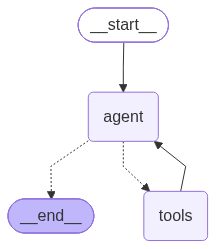

In [8]:
workflow = StateGraph(State)

workflow.add_node("agent", agent_node)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", route_tools)
workflow.add_edge("tools", "agent")

memory = MemorySaver()
ptw_agent = workflow.compile(checkpointer=memory)

print("✅ Permit-to-Work Agent Graph compiled successfully!")
ptw_agent

In [9]:
def run_chat():
    """Interactive chat session for the Permit-to-Work Agent."""
    thread_id = str(uuid.uuid4())
    config = {"configurable": {"thread_id": thread_id}}

    print("=" * 70)
    print("🦺 PERMIT-TO-WORK AGENT  ·  HSE Officer")
    print(f"Session Thread ID: {thread_id}")
    print("Type 'exit', 'quit' or 'break' to end the session.")
    print("=" * 70 + "\n")

    # Optional welcome
    print("Agent: Hi sir, I'm the Permit-to-Work Agent. "
          "I track hot-work, confined-space and work-at-height context; "
          "auto-surface violations from cameras + MES. Ask me anything.\n")

    while True:
        user_input = input("You (Sir): ").strip()
        if not user_input:
            continue
        if user_input.lower() in ["exit", "quit", "break"]:
            print("\nExiting Permit-to-Work session. Stay safe, sir!")
            break

        print("\nAgent is analysing permits & site risk...\n")

        events = ptw_agent.stream(
            {"messages": [HumanMessage(content=user_input)]},
            config=config,
            stream_mode="values"
        )

        for event in events:
            if "messages" in event:
                last_msg = event["messages"][-1]
                if isinstance(last_msg, AIMessage) and not last_msg.tool_calls and last_msg.content:
                    print(f"Agent: {last_msg.content}\n")
                    print("-" * 70)

# Start the chatbot
run_chat()

🦺 PERMIT-TO-WORK AGENT  ·  HSE Officer
Session Thread ID: 8af2d594-93bc-4728-b8bf-57c0670d7e4e
Type 'exit', 'quit' or 'break' to end the session.

Agent: Hi sir, I'm the Permit-to-Work Agent. I track hot-work, confined-space and work-at-height context; auto-surface violations from cameras + MES. Ask me anything.


Agent is analysing permits & site risk...



13:03:33 - LiteLLM:WARNING: vertex_and_google_ai_studio_gemini.py:1095 - DeprecationWarning: `temperature`, `top_p`, and `top_k` continue to function for Gemini 3+ (gemini-3.5-flash-lite) but are planned for removal in a future release. Move sampling guidance into the `system` instructions instead.
13:03:35 - LiteLLM:WARNING: vertex_and_google_ai_studio_gemini.py:1095 - DeprecationWarning: `temperature`, `top_p`, and `top_k` continue to function for Gemini 3+ (gemini-3.5-flash-lite) but are planned for removal in a future release. Move sampling guidance into the `system` instructions instead.


Agent: Hello sir, how can I assist you with site safety, active permits, or HSE incidents today?

----------------------------------------------------------------------


13:03:43 - LiteLLM:WARNING: vertex_and_google_ai_studio_gemini.py:1095 - DeprecationWarning: `temperature`, `top_p`, and `top_k` continue to function for Gemini 3+ (gemini-3.5-flash-lite) but are planned for removal in a future release. Move sampling guidance into the `system` instructions instead.



Agent is analysing permits & site risk...



13:03:45 - LiteLLM:WARNING: vertex_and_google_ai_studio_gemini.py:1095 - DeprecationWarning: `temperature`, `top_p`, and `top_k` continue to function for Gemini 3+ (gemini-3.5-flash-lite) but are planned for removal in a future release. Move sampling guidance into the `system` instructions instead.
13:03:47 - LiteLLM:WARNING: vertex_and_google_ai_studio_gemini.py:1095 - DeprecationWarning: `temperature`, `top_p`, and `top_k` continue to function for Gemini 3+ (gemini-3.5-flash-lite) but are planned for removal in a future release. Move sampling guidance into the `system` instructions instead.
13:03:48 - LiteLLM:WARNING: vertex_and_google_ai_studio_gemini.py:1095 - DeprecationWarning: `temperature`, `top_p`, and `top_k` continue to function for Gemini 3+ (gemini-3.5-flash-lite) but are planned for removal in a future release. Move sampling guidance into the `system` instructions instead.


Agent: Sir, I searched the system for specific work-at-height or fall protection incidents and found no direct records logged under those classes. However, the system currently tracks prominent PPE violations (such as missing helmets and vests) predominantly concentrated around **Camera 6**. 

Here is a summary of recent high-priority violation events captured on Camera 6:

| Incident ID | Camera | Violation Class | Started At | Status | Duration (s) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **3611** | Camera 6 | No-Helmet | 2026-08-13 09:55:53 | Escalated | 16s |
| **3608** | Camera 6 | No-Vest | 2026-08-13 09:55:37 | Escalated | 12s |
| **3607** | Camera 6 | No-Helmet | 2026-08-13 09:55:23 | Escalated | 11s |
| **3603** | Camera 6 | No-Vest | 2026-08-13 09:54:52 | Escalated | 12s |
| **3601** | Camera 6 | No-Vest | 2026-08-13 09:54:26 | Escalated | 18s |

Would you like me to check active maintenance windows or work orders associated with high-risk areas, sir?

----------------